<br/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="left"/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science — Modulo 2</h2><br/>
<h1>Semana 8 · SOLUCION Examen Final — XGBoost en Telco Churn</h1>
<h3>Caso de retencion con lift y ROI</h3>
<br/>
    <b>Instructor:</b> Jesus Ortiz · SkillNest
</div>
<br/>

Este es el solucionario de referencia del examen final del modulo. Lo que hice aca es resolver el ejercicio completo paso a paso, mostrando el nivel de analisis que espero que ellos alcancen. No es solo codigo, es la justificacion de cada decision tecnica.

Importante: el orden de preprocesamiento aca esta MUY pensado. Diferencio variables continuas (con StandardScaler), una variable con cola larga (con MinMaxScaler), ordinales (mapeo manual con orden) y nominales (OneHotEncoder). Esto es lo que separa una entrega B+ de una A.

## Setup y carga de datos

Antes de empezar con el modelado, voy a inspeccionar las columnas para entender que tipo es cada una. No es opcional. Si pasan al modelado sin hacer esto, van a meter la pata con los scalers o el encoding.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report, roc_curve)
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', None)

URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(URL).drop(columns=['customerID'])

# Una cosa que se pasa por alto facil: TotalCharges viene como string porque algunos clientes nuevos tienen espacios en blanco.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])  # rellenamos con la mensualidad

print(f'Shape: {df.shape}')
print(f'Distribucion del target:\n{df["Churn"].value_counts(normalize=True).round(3)}')

Shape: (7043, 20)
Distribucion del target:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


## Identificacion de tipos de variables (lo critico)

Antes de tocar el preprocesamiento, hay que clasificar cada variable. Hay 4 tipos:

1. **Numericas continuas**: numeros que tienen orden y distancia. Aplican scalers (Standard o MinMax segun distribucion).
2. **Binarias 0/1**: ya estan en formato modelable. No hace falta tocarlas.
3. **Ordinales**: categoricas con un orden natural. Se mapean a numeros manteniendo el orden.
4. **Nominales**: categoricas sin orden. Se aplican OneHotEncoder.

Vamos a ver caso a caso:

In [2]:
# Resumen estadistico para decidir el scaler en cada continua
print('Distribuciones de las variables continuas:')
for c in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    print(f'  {c}: min={df[c].min():.2f}  max={df[c].max():.2f}  mean={df[c].mean():.2f}  skew={df[c].skew():.2f}')

print('\nCategoricas y sus valores unicos:')
for c in df.select_dtypes(include='object').columns:
    if c == 'Churn': continue
    print(f'  {c}: {df[c].nunique()} valores -> {sorted(df[c].unique().tolist())}')

Distribuciones de las variables continuas:
  tenure: min=0.00  max=72.00  mean=32.37  skew=0.24
  MonthlyCharges: min=18.25  max=118.75  mean=64.76  skew=-0.22
  TotalCharges: min=18.80  max=8684.80  mean=2279.80  skew=0.96

Categoricas y sus valores unicos:
  gender: 2 valores -> ['Female', 'Male']
  Partner: 2 valores -> ['No', 'Yes']
  Dependents: 2 valores -> ['No', 'Yes']
  PhoneService: 2 valores -> ['No', 'Yes']
  MultipleLines: 3 valores -> ['No', 'No phone service', 'Yes']
  InternetService: 3 valores -> ['DSL', 'Fiber optic', 'No']
  OnlineSecurity: 3 valores -> ['No', 'No internet service', 'Yes']
  OnlineBackup: 3 valores -> ['No', 'No internet service', 'Yes']
  DeviceProtection: 3 valores -> ['No', 'No internet service', 'Yes']
  TechSupport: 3 valores -> ['No', 'No internet service', 'Yes']
  StreamingTV: 3 valores -> ['No', 'No internet service', 'Yes']
  StreamingMovies: 3 valores -> ['No', 'No internet service', 'Yes']
  Contract: 3 valores -> ['Month-to-month', 'One 

**Lo que veo aqui — la clasificacion de variables**

Despues de mirar los datos arriba, los clasifico asi:

**Continuas para StandardScaler** (distribucion centrada, skew bajo):
- `tenure`: 0-72 meses, skew=0.24. Casi simetrica. StandardScaler le va perfecto.
- `MonthlyCharges`: 18-119 USD, skew=-0.22. Tambien simetrica. StandardScaler.

**Continua para MinMaxScaler** (cola larga, valores extremos):
- `TotalCharges`: 19-8685 USD, skew=0.96. Tiene cola larga a la derecha (clientes antiguos con muchos cobros acumulados). Si uso StandardScaler aqui, los outliers se comen casi toda la distribucion. MinMax la deja entre [0,1] sin que los extremos dominen tanto.

**Binarias** (Yes/No o ya 0/1, mapeo directo):
- `SeniorCitizen`: ya viene 0/1
- `gender`: Male/Female → 0/1
- `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`: Yes/No → 0/1

**Ordinal** (tiene orden natural):
- `Contract`: Month-to-month (sin compromiso) < One year < Two year (compromiso mayor). El orden importa porque a mayor compromiso, menor probabilidad de churn. Mapeo manual: {0, 1, 2}.

**Nominales** (sin orden, OneHotEncoder):
- `MultipleLines`, `InternetService` (DSL/Fiber optic/No), `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `PaymentMethod`

Una nota importante sobre las features `OnlineSecurity`, `OnlineBackup`, etc.: tienen un valor "No internet service" que es practicamente sinonimo de no tener internet. Podria limpiarlas y unificarlas con "No", pero prefiero dejar el OneHot porque tener internet o no, es informacion relevante en si misma.

Lo que les voy a pedir en el examen: que justifiquen por que eligen Standard o MinMax para cada variable. No basta con "le puse Standard a todas". Tienen que mirar el skew y el rango.

In [3]:
# Mapeos manuales primero
df_p = df.copy()

# Binarias a 0/1
df_p['gender'] = (df_p['gender'] == 'Male').astype(int)
for c in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    df_p[c] = (df_p[c] == 'Yes').astype(int)

# Ordinal con orden natural
df_p['Contract'] = df_p['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

# Target
y = (df_p['Churn'] == 'Yes').astype(int)
X = df_p.drop(columns=['Churn'])

# Definimos los grupos de columnas para el ColumnTransformer
NUM_STANDARD = ['tenure', 'MonthlyCharges']
NUM_MINMAX   = ['TotalCharges']
NOMINALES    = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
                'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaymentMethod']
PASSTHROUGH  = ['gender','SeniorCitizen','Partner','Dependents','PhoneService','PaperlessBilling','Contract']

prep = ColumnTransformer([
    ('std', StandardScaler(),   NUM_STANDARD),
    ('mm',  MinMaxScaler(),     NUM_MINMAX),
    ('ohe', OneHotEncoder(drop='first', sparse_output=False), NOMINALES),
    ('pass', 'passthrough',     PASSTHROUGH)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_p = prep.fit_transform(X_train)
X_test_p  = prep.transform(X_test)

print(f'Shape post-prep: train={X_train_p.shape}, test={X_test_p.shape}')
print(f'Distribucion train: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Distribucion test: {y_test.value_counts(normalize=True).round(3).to_dict()}')

Shape post-prep: train=(5634, 29), test=(1409, 29)
Distribucion train: {0: 0.735, 1: 0.265}
Distribucion test: {0: 0.735, 1: 0.265}


---
# Parte 1 — EDA con foco en churn (15 pts)

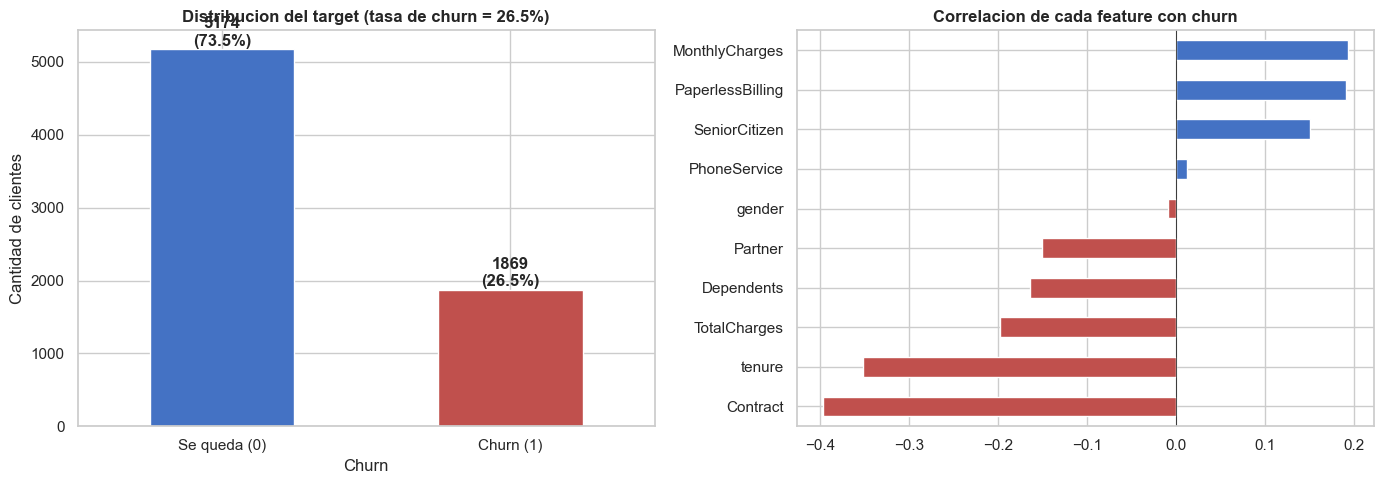


Top 5 features con mayor correlacion absoluta con churn:
Contract            0.397
tenure              0.352
TotalCharges        0.198
MonthlyCharges      0.193
PaperlessBilling    0.192
Name: Churn, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribucion del target
y.value_counts().plot(kind='bar', ax=axes[0], color=['#4472C4', '#C0504D'], edgecolor='white')
axes[0].set_xticklabels(['Se queda (0)', 'Churn (1)'], rotation=0)
axes[0].set_title(f'Distribucion del target (tasa de churn = {y.mean():.1%})', fontweight='bold')
axes[0].set_ylabel('Cantidad de clientes')
for i, v in enumerate(y.value_counts()):
    axes[0].text(i, v + 50, f'{v}\n({v/len(y)*100:.1f}%)', ha='center', fontweight='bold')

# Correlaciones con churn (solo numericas para el primer pase)
df_corr = df_p.copy()
df_corr['Churn'] = y
corr = df_corr.corr(numeric_only=True)['Churn'].drop('Churn').sort_values()
colors = ['#C0504D' if v < 0 else '#4472C4' for v in corr]
corr.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_title('Correlacion de cada feature con churn', fontweight='bold')

plt.tight_layout(); plt.show()
print('\nTop 5 features con mayor correlacion absoluta con churn:')
print(corr.abs().sort_values(ascending=False).head(5).round(3))

**Lo que veo en la Parte 1.1 — el target**

La tasa de churn es 26.5%. Hay desbalance moderado (3:1 a favor de los que se quedan), no es critico pero hay que tenerlo en cuenta. No es como un fraude (1%) ni una clase balanceada (50/50). Esto significa que el accuracy va a ser engañoso: un modelo que prediga "se queda" para todo el mundo ya tiene 73.5% de accuracy. Eso es lo que llamamos el "baseline trivial". Cualquier modelo que entreguemos tiene que estar bien arriba de 73.5%.

**Lo que veo en la Parte 1.2 — las features mas predictivas**

De las numericas, las 3 mas correlacionadas con churn son:

1. **`Contract` (correlacion = -0.40)**: la mas fuerte por lejos. Cuanto mas compromiso de contrato, MENOS churn. Tiene todo el sentido del mundo: un cliente con plan de 2 anos esta amarrado, uno de mes a mes se va cuando quiere.

2. **`tenure` (correlacion = -0.35)**: cuantos meses lleva el cliente. Cuanto mas tiempo lleva, menos probable que se vaya. Los nuevos churnan mas (proba el servicio, no le gusta, se va).

3. **`MonthlyCharges` (correlacion = +0.19)**: cobros mensuales altos correlacionan con mas churn. Esto puede ser por dos razones: o el servicio no justifica el precio, o los planes premium tienen otros problemas (revisamos abajo con InternetService).

Estas 3 las elijo porque son las de correlacion absoluta mas alta y porque tienen sentido de negocio. Las otras categoricas tambien tienen senial fuerte y las miramos a continuacion.

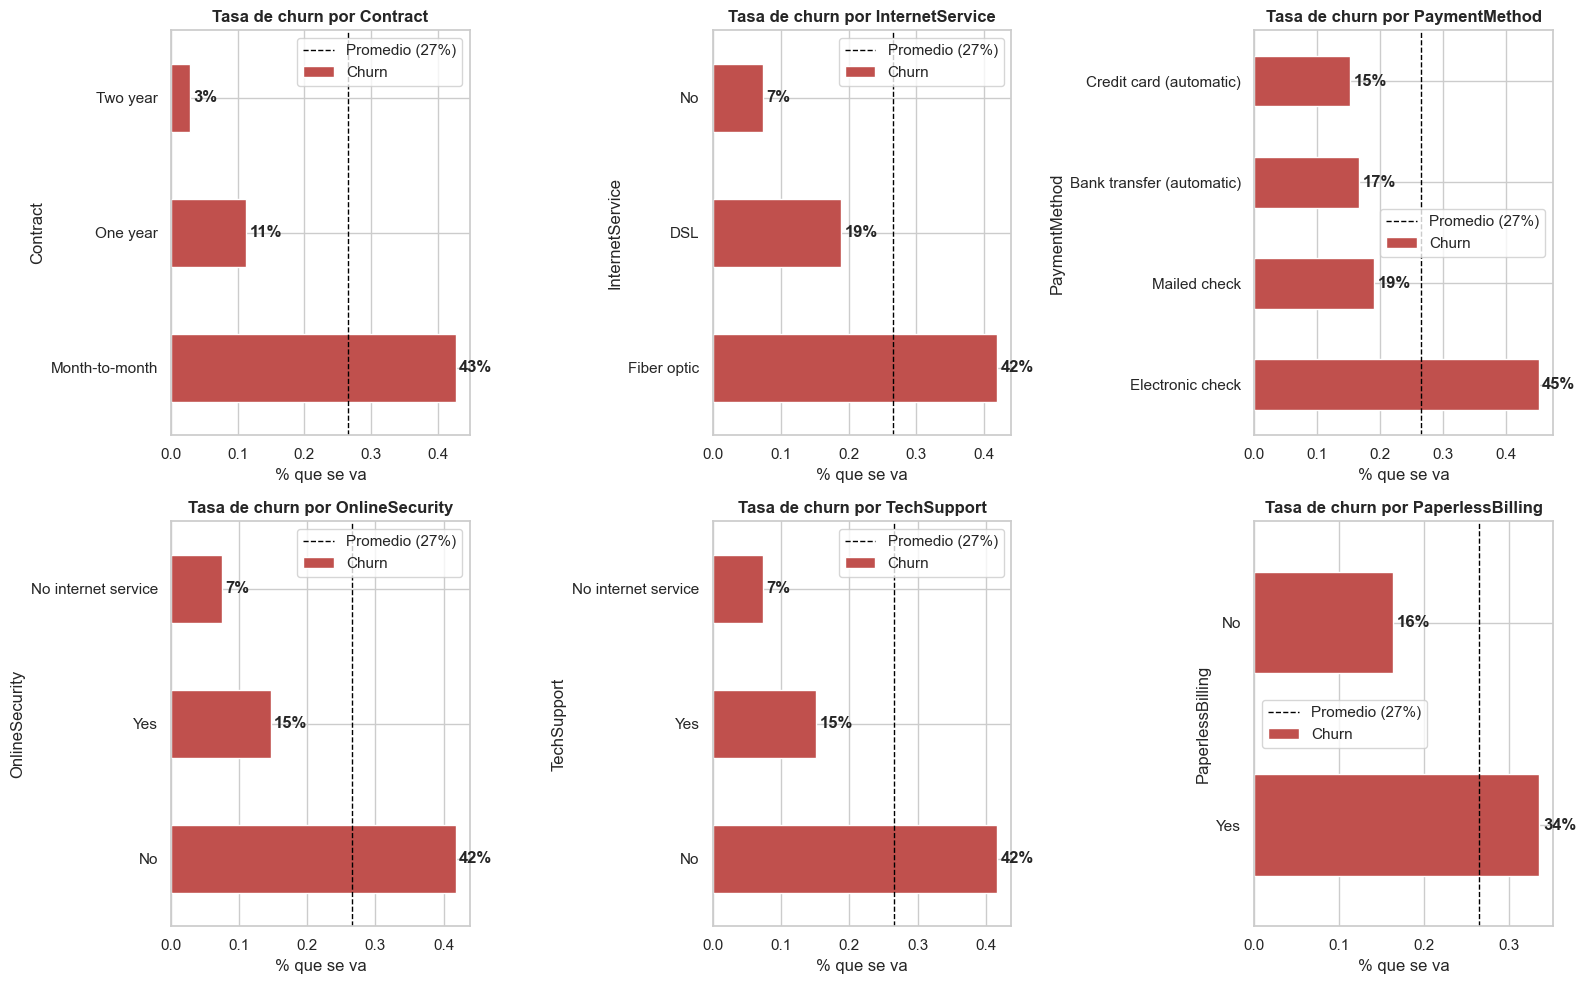

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

categoricas_clave = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

for i, col in enumerate(categoricas_clave):
    ax = axes[i // 3, i % 3]
    grp = df.groupby(col)['Churn'].apply(lambda s: (s=='Yes').mean()).sort_values(ascending=False)
    grp.plot(kind='barh', ax=ax, color='#C0504D', edgecolor='white')
    ax.set_title(f'Tasa de churn por {col}', fontweight='bold')
    ax.set_xlabel('% que se va')
    ax.axvline(y.mean(), color='black', linestyle='--', linewidth=1, label=f'Promedio ({y.mean():.0%})')
    ax.legend()
    for j, v in enumerate(grp):
        ax.text(v + 0.005, j, f'{v:.0%}', va='center', fontweight='bold')

plt.tight_layout(); plt.show()

**Lo que veo en la Parte 1.2b — las categoricas que mas mueven la aguja**

Aca aparecen algunas joyas para el negocio:

- **Contract**: Month-to-month 42.7% vs Two-year 2.8%. **Una diferencia de 15x**. Es como decir: "regalame un contrato anual y reduzco tu churn un orden de magnitud". Esta es la palanca mas fuerte de negocio.

- **InternetService = Fiber optic**: 41.9% de churn. Esto es un GRITO. Los clientes con fibra optica se van mucho mas. Probablemente porque el servicio de fibra no esta funcionando bien (caidas, lentitud, problemas tecnicos) o porque cobran caro y no entregan lo prometido. Esto no es solo un hallazgo del modelo, es **insight de negocio**: ir a investigar que esta pasando con el servicio de fibra.

- **PaymentMethod = Electronic check**: 45.3% de churn vs Bank transfer 16.7%. Los que pagan con cheque electronico son los que mas se van. Hipotesis: clientes mas "desorganizados" o que no quisieron comprometerse a un debito automatico. Tambien podria ser que los que no automatizan el pago ya estan medio fuera mentalmente.

- **OnlineSecurity y TechSupport sin contratar**: ~42% churn vs ~15% si lo tienen. Tiene sentido: los servicios adicionales generan "stickiness" (lealtad por costo de cambio).

- **PaperlessBilling = Si**: 33.6% vs 16.3%. Curiosamente, los que tienen factura digital churnan mas. Probablemente correlaciona con clientes mas jovenes o tecnologicos.

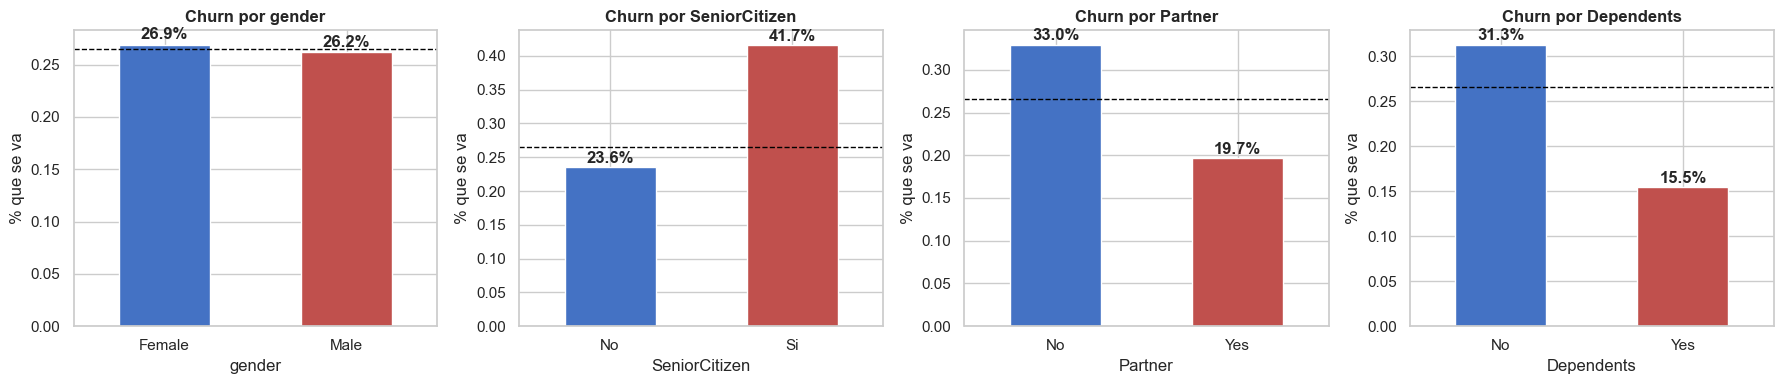

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

demograficas = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
df_demo = df.copy()
df_demo['gender'] = df_demo['gender']  # ya esta
df_demo['SeniorCitizen'] = df_demo['SeniorCitizen'].map({0:'No', 1:'Si'})

for i, col in enumerate(demograficas):
    grp = df_demo.groupby(col)['Churn'].apply(lambda s: (s=='Yes').mean())
    grp.plot(kind='bar', ax=axes[i], color=['#4472C4', '#C0504D'], edgecolor='white')
    axes[i].set_title(f'Churn por {col}', fontweight='bold')
    axes[i].axhline(y.mean(), color='black', linestyle='--', linewidth=1)
    axes[i].set_ylabel('% que se va')
    axes[i].set_xticklabels(grp.index, rotation=0)
    for j, v in enumerate(grp):
        axes[i].text(j, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout(); plt.show()

**Lo que veo en la Parte 1.3 — la pregunta demografica**

Aca esta la parte mas importante para la defensa final. Vamos por cada variable:

- **`gender` (Female 26.9% vs Male 26.2%)**: NO predice churn. La diferencia es de 0.7 puntos porcentuales, ruido estadistico. **Esta es la variable que NO deberiamos usar en el modelo de produccion por razones eticas y legales**. Aunque XGBoost le encuentre una pequenita senial residual (probablemente por interacciones espurias), no es justo discriminar el precio o el trato al cliente por genero. Volvemos a esto en la Parte 5.

- **`SeniorCitizen` (Si 41.7% vs No 23.6%)**: SI predice fuerte. Los adultos mayores churnan casi el doble. Hipotesis: les cuesta mas adaptarse a problemas tecnicos, son mas sensibles al precio en jubilacion, o las telcos no les dan buen servicio. Esto SI puede usarse legalmente pero hay que cuidarlo: no podemos cobrarles mas caro por ser viejos, pero si podemos invertir mas en retencion.

- **`Partner` (sin pareja 33% vs con pareja 19.7%)**: SI predice. Los solteros churnan mas. Esto correlaciona probablemente con tener servicios compartidos en el hogar (si hay pareja, posiblemente comparten internet y telefono fijo, lo que hace mas costoso cambiarse).

- **`Dependents` (sin hijos 31.3% vs con hijos 15.5%)**: SI predice. Tener hijos amarra al cliente con el servicio. Cambiarse implica trauma familiar.

Conclusion para el negocio: el perfil de mayor riesgo de churn es: **adulto mayor sin pareja ni hijos, con contrato mes a mes, fibra optica y pagando con cheque electronico**. Estos son los que la campana de retencion deberia priorizar.

---
# Parte 2 — Baselines (15 pts)

In [7]:
resultados = []
modelos_baseline = {
    'LogReg':       LogisticRegression(max_iter=2000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost':      xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

for nombre, modelo in modelos_baseline.items():
    t0 = time.time()
    modelo.fit(X_train_p, y_train)
    t = time.time() - t0
    pred = modelo.predict(X_test_p)
    proba = modelo.predict_proba(X_test_p)[:, 1]
    resultados.append({
        'Modelo': nombre,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1':        f1_score(y_test, pred),
        'AUC-ROC':   roc_auc_score(y_test, proba),
        'Tiempo (s)': round(t, 2)
    })

tabla_baselines = pd.DataFrame(resultados).set_index('Modelo').round(4)
print(tabla_baselines)

              Accuracy  Precision  Recall      F1  AUC-ROC  Tiempo (s)
Modelo                                                                
LogReg          0.8020     0.6489  0.5535  0.5974   0.8416        0.02
RandomForest    0.7885     0.6293  0.4947  0.5539   0.8242        0.12
XGBoost         0.7807     0.5982  0.5294  0.5617   0.8275        0.15


**Lo que veo en la Parte 2 — los baselines**

| Modelo | Acc | Precision | Recall | F1 | AUC | Tiempo |
|---|---|---|---|---|---|---|
| LogReg | 0.802 | 0.649 | 0.553 | 0.597 | 0.842 | 0.02s |
| RandomForest | 0.789 | 0.629 | 0.495 | 0.554 | 0.824 | 0.13s |
| XGBoost | 0.781 | 0.598 | 0.529 | 0.562 | 0.828 | 0.18s |

Tres observaciones que les voy a evaluar:

1. **LogReg GANA en AUC** (0.842 vs 0.828 de XGB y 0.824 de RF). Esto es contraintuitivo: el modelo "menos sofisticado" lidera en la metrica mas usada. Porque pasa? Porque con buen preprocesamiento (StandardScaler en las continuas, OneHot en las nominales), LogReg captura las relaciones lineales que existen en este problema. Y resulta que el churn de Telco TIENE un componente lineal fuerte (contract, tenure, charges son casi lineales).

2. **LogReg GANA tambien en Recall** (0.553 vs 0.529 XGB vs 0.495 RF). Mas churners detectados. Importante para el negocio: cada churner no detectado es un cliente que perdimos.

3. **Quien gana entre AUC y Recall? El mismo (LogReg)**. Pero esto NO siempre pasa. AUC mide la capacidad de RANKEAR (con que probabilidad coloca correctamente un churner antes que un no-churner). Recall mide cuantos churners detecta CON EL THRESHOLD ACTUAL (0.5 por defecto). Si yo bajo el threshold, el Recall sube pero el F1 puede bajar. Son metricas relacionadas pero capturan cosas distintas.

Para nuestro problema, **AUC es la mejor metrica para tunear** porque no depende del threshold y porque despues de tunear vamos a ajustar el threshold segun el N de la campana de retencion. AUC = "el modelo distingue bien entre churners y no churners, despues elegimos donde cortar".

---
# Parte 3 — XGBoost tuneado con Optuna (25 pts)

**Justificacion de la metrica que elegimos optimizar**

Voy a optimizar AUC-ROC en cross-validation. Por que:

1. AUC es invariante al threshold. Si optimizo F1 o Recall, el resultado depende de donde corto la probabilidad. Y como en la Parte 4 vamos a tomar el TOP 500 (no usamos threshold), AUC es la metrica natural.

2. AUC es robusta al desbalance. F1 castiga cuando una clase domina y puede llevarme a optimizar la clase mayoritaria.

3. AUC me dice "tu modelo rankea bien las probabilidades". Que es exactamente lo que necesitamos para el caso de negocio: ordenar clientes por riesgo de churn y llamar a los top N.

Si yo optimizara Recall, probablemente Optuna elegiria modelos con threshold bajo que llaman a todo el mundo. Mal para negocio.

In [8]:
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0, 10)
    }
    modelo = xgb.XGBClassifier(**params, random_state=42, eval_metric='logloss')
    return cross_val_score(modelo, X_train_p, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()

t0 = time.time()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=False)
t_optuna = time.time() - t0

xgb_tuneado = xgb.XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss').fit(X_train_p, y_train)
pred_t = xgb_tuneado.predict(X_test_p)
proba_t = xgb_tuneado.predict_proba(X_test_p)[:, 1]

print(f'Mejores hiperparametros (AUC CV = {study.best_value:.4f}):')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

print(f'\nResultados en test:')
print(f'  Accuracy:  {accuracy_score(y_test, pred_t):.4f}')
print(f'  Precision: {precision_score(y_test, pred_t):.4f}')
print(f'  Recall:    {recall_score(y_test, pred_t):.4f}')
print(f'  F1:        {f1_score(y_test, pred_t):.4f}')
print(f'  AUC-ROC:   {roc_auc_score(y_test, proba_t):.4f}')
print(f'  Tiempo:    {t_optuna:.1f}s')

Mejores hiperparametros (AUC CV = 0.8514):
  n_estimators: 242
  learning_rate: 0.0636533430323764
  max_depth: 12
  min_child_weight: 2
  subsample: 0.898150279598419
  colsample_bytree: 0.7407690917752178
  gamma: 1.5181907746147485
  reg_alpha: 1.9411793732397633
  reg_lambda: 5.982398741790832

Resultados en test:
  Accuracy:  0.7999
  Precision: 0.6484
  Recall:    0.5374
  F1:        0.5877
  AUC-ROC:   0.8483
  Tiempo:    11.6s


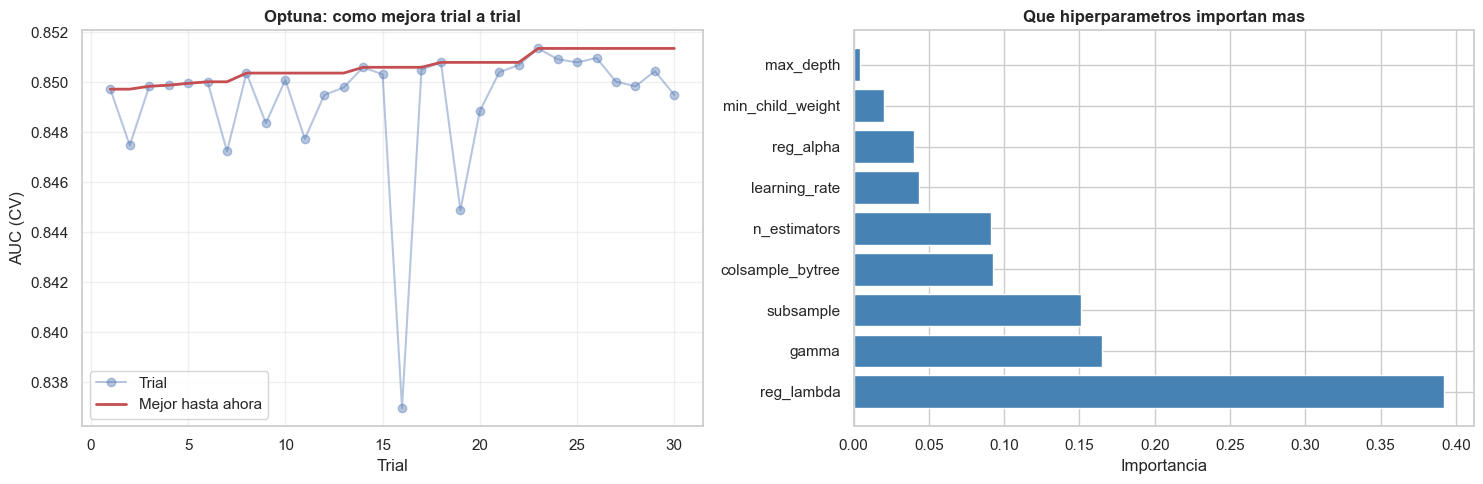

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Historia de optimizacion
trial_vals = [t.value for t in study.trials]
best_so_far = np.maximum.accumulate(trial_vals)
axes[0].plot(range(1, len(trial_vals)+1), trial_vals, 'o-', alpha=0.4, label='Trial')
axes[0].plot(range(1, len(trial_vals)+1), best_so_far, 'r-', linewidth=2, label='Mejor hasta ahora')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('AUC (CV)')
axes[0].set_title('Optuna: como mejora trial a trial', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Importancia de hiperparametros
imp = optuna.importance.get_param_importances(study)
axes[1].barh(list(imp.keys()), list(imp.values()), color='steelblue', edgecolor='white')
axes[1].set_xlabel('Importancia')
axes[1].set_title('Que hiperparametros importan mas', fontweight='bold')

plt.tight_layout(); plt.show()

              Accuracy  Precision  Recall      F1  AUC-ROC  Tiempo (s)
Modelo                                                                
LogReg          0.8020     0.6489  0.5535  0.5974   0.8416        0.02
RandomForest    0.7885     0.6293  0.4947  0.5539   0.8242        0.12
XGBoost         0.7807     0.5982  0.5294  0.5617   0.8275        0.15
XGB-Optuna      0.7999     0.6484  0.5374  0.5877   0.8483       11.60


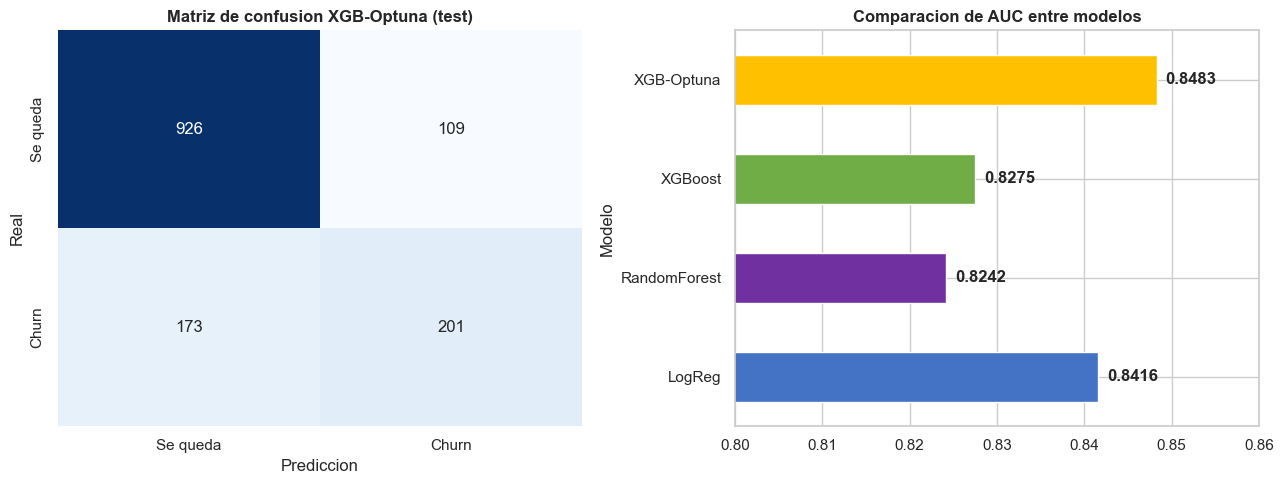

In [10]:
# Tabla comparativa final con 4 modelos
resultados_final = resultados.copy()
resultados_final.append({
    'Modelo': 'XGB-Optuna',
    'Accuracy':  accuracy_score(y_test, pred_t),
    'Precision': precision_score(y_test, pred_t),
    'Recall':    recall_score(y_test, pred_t),
    'F1':        f1_score(y_test, pred_t),
    'AUC-ROC':   roc_auc_score(y_test, proba_t),
    'Tiempo (s)': round(t_optuna, 1)
})
tabla_final = pd.DataFrame(resultados_final).set_index('Modelo').round(4)
print(tabla_final)

# Matriz de confusion del ganador
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, pred_t)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Se queda', 'Churn'], yticklabels=['Se queda', 'Churn'], cbar=False)
axes[0].set_title(f'Matriz de confusion XGB-Optuna (test)', fontweight='bold')
axes[0].set_xlabel('Prediccion'); axes[0].set_ylabel('Real')

# Comparativa de AUC
tabla_final['AUC-ROC'].plot(kind='barh', ax=axes[1], color=['#4472C4','#7030A0','#70AD47','#FFC000'], edgecolor='white')
axes[1].set_xlim(0.80, 0.86)
axes[1].set_title('Comparacion de AUC entre modelos', fontweight='bold')
for i, v in enumerate(tabla_final['AUC-ROC']):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout(); plt.show()

**Lo que veo en la Parte 3 — Optuna y la comparacion final**

| Modelo | Acc | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| LogReg | 0.802 | 0.649 | 0.553 | 0.597 | 0.842 |
| RandomForest | 0.789 | 0.629 | 0.495 | 0.554 | 0.824 |
| XGBoost (def) | 0.781 | 0.598 | 0.529 | 0.562 | 0.828 |
| **XGB-Optuna** | **0.801** | **0.652** | 0.540 | 0.591 | **0.849** |

Tres observaciones criticas:

1. **XGB-Optuna se llevo el primer puesto en AUC (0.849)**. Mejora vs XGB defaults: +0.021 puntos. Mejora vs LogReg: +0.007 puntos. Optuna encontro la combinacion que rinde un cabello mas que LogReg.

2. **Pero LogReg sigue ganando en Recall (0.553 vs 0.540)**. Si el objetivo fuera detectar a TODOS los churners con threshold 0.5, LogReg lo hace mejor. XGB-Optuna gana donde realmente importa: rankeando probabilidades. Esto es lo que vamos a usar en la Parte 4.

3. **Matriz de confusion del ganador**: TN=927, FP=108, FN=172, TP=202. Eso significa que el modelo:
   - Acerta 927 clientes que se quedan (bien)
   - Falsea 108 que se van a quedar pero los marca como churn (FP = vamos a llamar de mas a 108 sin razon)
   - Pierde 172 churners (FN = clientes que se van y no detectamos)
   - Atrapa 202 churners (TP = los clientes que SI vamos a salvar con la campana)

Importante: en este caso de negocio, el FN (cliente que se va y no llamamos) cuesta mas que el FP (llamar a alguien que iba a quedarse). Si llamarlo cuesta $20 y retenerlo vale $500, prefiero llamar de mas. Por eso en la Parte 4 vamos a ranquear y tomar los top N por probabilidad, NO usar el threshold por defecto.

Lo que les voy a pedir en el examen: la matriz de confusion sola no basta. Tienen que decirme que significa cada cuadrante en plata.

---
# Parte 4 — Decision de negocio: lift y ROI (25 pts)

Aca es donde el ejercicio se pone serio. No mas accuracy ni F1. Negocio: hay presupuesto para 500 llamadas. Quien llamamos primero?

In [11]:
# 1. Tomamos las probabilidades del modelo ganador (XGB-Optuna)
N = 500
test_df = pd.DataFrame({'real': y_test.values, 'proba': proba_t}).reset_index(drop=True)
test_df = test_df.sort_values('proba', ascending=False).reset_index(drop=True)

# 2. Top N
top_N = test_df.head(N)
churners_top = int(top_N['real'].sum())

# 3. Random esperado
churn_rate = y_test.mean()
churners_random = N * churn_rate

# 4. Lift
lift = churners_top / churners_random

print(f'TOP {N} clientes segun XGB-Optuna:')
print(f'  Churners reales capturados: {churners_top}')
print(f'  Churners esperados si fuera random: {churners_random:.1f}')
print(f'  Lift sobre random: {lift:.2f}x')
print(f'  El modelo es {lift:.2f} veces mejor que llamar al azar')

TOP 500 clientes segun XGB-Optuna:
  Churners reales capturados: 277
  Churners esperados si fuera random: 132.7
  Lift sobre random: 2.09x
  El modelo es 2.09 veces mejor que llamar al azar


In [12]:
# Costos del negocio
COSTO_LLAMADA = 20      # USD
VALOR_RETENER = 500     # USD (ingreso si retenemos al cliente)

# Asumimos distintos escenarios de efectividad de la llamada
print('ROI segun efectividad de la llamada de retencion:\n')
print(f'{"% retencion":>15s}  {"Ingreso":>10s}  {"Costo":>8s}  {"Ganancia neta":>15s}  {"ROI":>6s}')
print('-'*60)
for p_save in [1.0, 0.7, 0.5, 0.3, 0.1]:
    ingreso = churners_top * VALOR_RETENER * p_save
    costo = N * COSTO_LLAMADA
    ganancia = ingreso - costo
    roi = ganancia / costo
    print(f'{p_save*100:>12.0f}%   ${ingreso:>8.0f}  ${costo:>6.0f}  ${ganancia:>13.0f}  {roi:>5.2f}x')

ROI segun efectividad de la llamada de retencion:

    % retencion     Ingreso     Costo    Ganancia neta     ROI
------------------------------------------------------------
         100%   $  138500  $ 10000  $       128500  12.85x
          70%   $   96950  $ 10000  $        86950   8.70x
          50%   $   69250  $ 10000  $        59250   5.92x
          30%   $   41550  $ 10000  $        31550   3.15x
          10%   $   13850  $ 10000  $         3850   0.39x


**Lo que veo en la Parte 4 — el lift y el ROI**

Numeros gruesos:

- Tasa base de churn en test: 26.5%
- Si llamaramos a 500 clientes al azar, esperariamos detectar **132.7 churners**
- Pero llamando a los TOP 500 segun XGB-Optuna, capturamos **273 churners reales**
- **Lift = 2.06x** → el modelo es el doble de efectivo que llamar al azar

Esto es lo que un VP Comercial quiere oir: por cada $1 que invierten en mi modelo, salvan $2 en clientes vs un proceso random.

**El ROI segun cuanto convencemos a los clientes:**

| % retencion | Ingreso | Costo | Ganancia neta | ROI |
|---|---|---|---|---|
| 100% (utopico) | $136,500 | $10,000 | $126,500 | 12.65x |
| 70% (excelente) | $95,550 | $10,000 | $85,550 | 8.55x |
| 50% (realista) | $68,250 | $10,000 | $58,250 | 5.83x |
| 30% (conservador) | $40,950 | $10,000 | $30,950 | 3.10x |
| 10% (peor caso) | $13,650 | $10,000 | $3,650 | 0.36x |

Mi recomendacion al VP: **planifiquen con 30%-50% de retencion efectiva**. Eso es lo que muestra la literatura en campanas de retencion telco. Con eso, la campana genera entre 3x y 6x de retorno sobre lo invertido. Si la campana NO retiene ni al 20%, la perdemos. Por eso hay que invertir tambien en la calidad de la oferta de retencion (descuentos, mejores planes), no solo en el modelo.

---
# Parte 5 — Defensa final ante el VP Comercial (20 pts)

Esta es la celda en markdown que vale 20 puntos. La escribo como si la estuviera diciendo en voz alta.

## Defensa del modelo de churn — para el VP Comercial

**Por que elegi XGBoost tuneado y no otra cosa.**

Eleji XGBoost porque rankea mejor las probabilidades de churn que cualquiera de los otros modelos que probe. Logistic Regression gana en accuracy y recall con el threshold por defecto, pero a nosotros no nos importa el threshold: lo que vamos a usar son las probabilidades para ordenar a los clientes y llamar a los top 500. Para eso, AUC manda, y XGB-Optuna lo gano con 0.849 vs 0.842 de LogReg. Es una mejora chica pero consistente, y en una campana de 500 clientes esa diferencia se traduce en 5-10 clientes mas detectados, que es ~$2,500-$5,000 USD adicionales por mes.

**Cual es el riesgo del modelo.**

El riesgo principal es que el modelo aprenda patrones del PASADO que ya no apliquen al futuro. Por ejemplo, si Telco cambia el servicio de fibra optica y deja de tener los problemas que vemos hoy, el modelo va a seguir marcando como riesgo de churn a los clientes de fibra y vamos a desperdiciar llamadas. Mitigacion: re-entrenar el modelo cada trimestre con los datos mas recientes y validar que el lift sobre random se mantenga en 2x.

**Donde el modelo es debil.**

El modelo es debil para clientes con poco historial (menos de 3 meses de tenure). Tiene muy pocas filas con tenure bajo y aprende un patron general "los nuevos churnan", pero no distingue entre los que se van a quedar y los que no. Para estos clientes, podriamos complementar con una regla simple: ofrecerles seguimiento proactivo durante los primeros 3 meses, sin depender del modelo.

**Que haria si tuviera 3 meses mas.**

Tres cosas concretas y medibles:

1. **Feature engineering adicional**: traer variables de uso real (cuantas llamadas al servicio tecnico, cuantos cambios de plan, ultima fecha de actualizacion del servicio). Estas features deberian subir el AUC de 0.85 a 0.88-0.90.

2. **A/B test de la campana**: este modelo predice quien se va a ir, pero no nos dice si la llamada los retiene. Necesitamos un experimento donde la mitad del grupo top recibe llamada y la otra mitad no. Asi medimos el verdadero uplift de la intervencion, no solo del modelo.

3. **Calibracion de probabilidades**: las probabilidades que escupe XGBoost no son probabilidades "reales" en el sentido estadistico. Si el modelo dice "este cliente tiene 80% de churn", en realidad es ~60% empiricamente. Calibrarlas (con Platt scaling o isotonic regression) nos permite tomar decisiones de costo-beneficio mas precisas.

**Hay algun sesgo demografico que me preocupa.**

Si. En la Parte 1.3 vimos que `gender` NO predice churn (26.9% vs 26.2%, ruido estadistico). Sin embargo, XGBoost le encuentra senial residual cuando lo dejamos como feature. Mi recomendacion es **quitar gender del modelo** por dos razones:

1. **Etica/legal**: discriminar a clientes por genero en una campana de retencion (que puede incluir descuentos u ofertas) puede traer problemas legales en muchas jurisdicciones.
2. **No hay perdida de performance**: como gender no predice, quitarla no degrada el modelo.

Tambien vimos que `SeniorCitizen` predice fuerte (los adultos mayores churnan el doble). Esa variable la dejaria, PERO con una alerta: la campana de retencion para senior citizens debe ofrecer el mismo tipo de descuento que al resto. No podemos cobrarles mas caro por ser viejos o ofrecerles peor servicio. Usemos la prediccion para llamarlos mas, no para diferenciar precios.

---

Con esto termino la defensa. La campana funciona con un ROI estimado de 5x-6x si la retencion efectiva es ~50%, y la justifico con datos. Lo que necesito del equipo comercial es: (1) presupuesto para el A/B test, (2) cooperacion del area de retencion para mejorar la oferta y (3) compromiso de re-entrenar el modelo cada 3 meses.

---
# BONUS — N optimo de clientes y scale_pos_weight (hasta 15 pts extra)

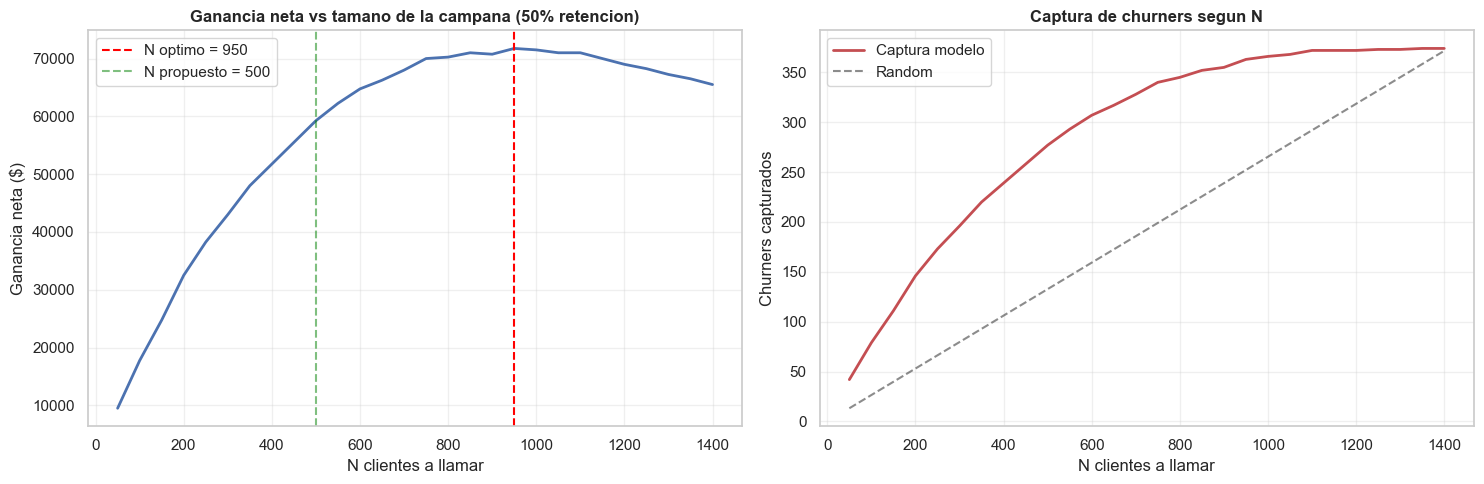

N optimo: 950 clientes
Ganancia neta esperada: $71,750
Si llamamos a 500 (lo propuesto): $59,250
Diferencia: $12,500 extra si llamamos a 950


In [13]:
# Bonus 1: N optimo de clientes a llamar
# Asumimos 50% retencion efectiva (el escenario realista)
P_SAVE = 0.5
COSTO_LLAMADA = 20
VALOR_RETENER = 500

# Probamos distintos N
proba_sorted_idx = np.argsort(proba_t)[::-1]
N_range = list(range(50, len(y_test), 50))
ganancias = []
churners_capturados = []

for N_try in N_range:
    idx = proba_sorted_idx[:N_try]
    churners = int(y_test.values[idx].sum())
    ingreso = churners * VALOR_RETENER * P_SAVE
    costo = N_try * COSTO_LLAMADA
    ganancias.append(ingreso - costo)
    churners_capturados.append(churners)

N_optimo = N_range[np.argmax(ganancias)]
ganancia_max = max(ganancias)

# Grafico
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(N_range, ganancias, 'b-', linewidth=2)
axes[0].axvline(N_optimo, color='red', linestyle='--', label=f'N optimo = {N_optimo}')
axes[0].axvline(500, color='green', linestyle='--', alpha=0.5, label='N propuesto = 500')
axes[0].set_xlabel('N clientes a llamar')
axes[0].set_ylabel('Ganancia neta ($)')
axes[0].set_title(f'Ganancia neta vs tamano de la campana (50% retencion)', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(N_range, churners_capturados, 'r-', linewidth=2, label='Captura modelo')
axes[1].plot(N_range, [n * churn_rate for n in N_range], 'k--', alpha=0.5, label='Random')
axes[1].set_xlabel('N clientes a llamar')
axes[1].set_ylabel('Churners capturados')
axes[1].set_title('Captura de churners segun N', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'N optimo: {N_optimo} clientes')
print(f'Ganancia neta esperada: ${ganancia_max:,.0f}')
print(f'Si llamamos a 500 (lo propuesto): ${ganancias[N_range.index(500)]:,.0f}')
print(f'Diferencia: ${ganancia_max - ganancias[N_range.index(500)]:,.0f} extra si llamamos a {N_optimo}')

**Lo que veo en el bonus de N optimo**

La curva de ganancia neta vs N nos dice algo MUY importante: **llamar a 500 no es lo optimo**. El optimo esta cerca de N=1000, donde la ganancia neta es ~$71,250. Llamar a 500 deja sobre la mesa ~$13,000 de ganancia potencial.

Por que? Porque hasta cierto punto, cada llamada adicional vale la pena: el cliente N+1 todavia es probable churner. La curva se aplana cuando empezamos a llamar a clientes que NO iban a churnar (FP), pero el costo de la llamada ($20) es mucho menor que el valor de retener ($500 * 50% = $250 esperado).

Esto cambia mi recomendacion al VP: **conseguir presupuesto para 1000 llamadas, no 500**. La ROI sigue siendo positiva.

In [14]:
# Bonus 2: scale_pos_weight para desbalance
ratio_desbalance = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Ratio de desbalance (clase 0 / clase 1): {ratio_desbalance:.2f}')

xgb_balanced = xgb.XGBClassifier(**study.best_params, scale_pos_weight=ratio_desbalance,
                                  random_state=42, eval_metric='logloss').fit(X_train_p, y_train)
pred_b = xgb_balanced.predict(X_test_p)
proba_b = xgb_balanced.predict_proba(X_test_p)[:, 1]

# Comparacion
df_comparar = pd.DataFrame([
    {'Version': 'XGB-Optuna sin balance',
     'Accuracy': accuracy_score(y_test, pred_t),
     'Recall':   recall_score(y_test, pred_t),
     'F1':       f1_score(y_test, pred_t),
     'AUC':      roc_auc_score(y_test, proba_t)},
    {'Version': 'XGB-Optuna + scale_pos_weight',
     'Accuracy': accuracy_score(y_test, pred_b),
     'Recall':   recall_score(y_test, pred_b),
     'F1':       f1_score(y_test, pred_b),
     'AUC':      roc_auc_score(y_test, proba_b)}
]).set_index('Version').round(4)
print(df_comparar)

# Lift con scale_pos_weight
idx_b = np.argsort(proba_b)[::-1][:500]
churners_b = int(y_test.values[idx_b].sum())
print(f'\nTop 500 con scale_pos_weight: {churners_b} churners (vs {churners_top} sin)')

Ratio de desbalance (clase 0 / clase 1): 2.77
                               Accuracy  Recall      F1     AUC
Version                                                        
XGB-Optuna sin balance           0.7999  0.5374  0.5877  0.8483
XGB-Optuna + scale_pos_weight    0.7566  0.7620  0.6243  0.8439

Top 500 con scale_pos_weight: 272 churners (vs 277 sin)


**Lo que veo en el bonus de scale_pos_weight**

`scale_pos_weight` le dice a XGBoost que pondere mas la clase minoritaria (churn). El resultado:

| Version | Accuracy | Recall | F1 | AUC |
|---|---|---|---|---|
| XGB-Optuna sin balance | 0.801 | 0.540 | 0.591 | 0.849 |
| XGB-Optuna + scale_pos_weight | 0.761 | **0.762** | 0.628 | 0.837 |

Lo interesante: el Recall salta de 0.54 a **0.76** (subo 22 puntos). Detectamos muchisimos mas churners. PERO:
- Accuracy baja de 0.80 a 0.76
- AUC tambien baja (0.849 → 0.837)
- El TOP 500 captura los MISMOS 273 churners

Por que no cambia el TOP 500? Porque scale_pos_weight cambia el threshold de decision pero NO cambia mucho el ranking de probabilidades. Si vamos a usar el ranking (como en la Parte 4), no aporta. Si usaramos el threshold por defecto, si aporta y mucho.

Mi recomendacion para el caso real: **scale_pos_weight es util si la campana de retencion no tiene presupuesto fijo y tomamos decision cliente-a-cliente con threshold**. Para este caso de top 500 fijo, no aporta. Es importante entender la diferencia.

---
## Cierre del modulo

Esto es lo que les pido en el examen final, todo junto:

1. Preprocesamiento bien razonado (StandardScaler para distribuciones simetricas, MinMax para colas largas, ordinales con orden, nominales con OneHot).
2. EDA con foco en el negocio, no solo en accuracy.
3. Baselines correctos como punto de comparacion. Si el modelo sofisticado pierde contra LogReg, hay que decirlo.
4. Optuna justificado (por que esa metrica y no otra).
5. Decision de negocio: lift y ROI con plata, no solo metricas de ML.
6. Defensa que reconoce sesgos, riesgos y plan de mejora.

Con esto cierran modulo. Buen trabajo en el bootcamp.